# Session 3 — Sentence-Level Analysis
## Measure 3: Sentence Embeddings (LLMs as Semantic Encoders)

### What are Sentence Embeddings?
Sentence embeddings are **dense vector representations** of sentences that capture their semantic meaning in a high-dimensional space. Unlike traditional word-based approaches, sentence embeddings encode the entire meaning of a sentence into a single fixed-length vector (typically 384-768 dimensions).

### How They Work
Modern sentence embedding models (like SBERT - Sentence-BERT) use **transformer architectures** pre-trained on massive text corpora. These models:
- Convert sentences into numerical vectors where semantically similar sentences are close together in vector space
- Capture context, syntax, and semantic relationships
- Enable comparison of sentences based on meaning rather than just word overlap

### Key Applications in NLP
1. **Semantic Similarity**: Measure how similar two sentences are in meaning
2. **Information Retrieval**: Find relevant documents or passages based on semantic search
3. **Text Clustering**: Group similar sentences or documents together
4. **Duplicate Detection**: Identify paraphrases or semantically identical content
5. **Question Answering**: Match questions with relevant answers
6. **Content Recommendation**: Suggest similar content based on semantic understanding

### Why Use Sentence Embeddings?
- **Beyond Keywords**: Captures meaning even when different words are used
- **Efficient**: Pre-computed embeddings allow fast similarity comparisons
- **Robust**: Works across different phrasings and writing styles
- **Multilingual**: Many models support cross-lingual semantic search

### This Demonstration
We'll use the **all-MiniLM-L6-v2** model to:
- Encode example sentences into semantic vectors
- Visualize their relationships in 2D space using PCA
- Compute similarity scores between sentence pairs

In [1]:
# First, add the data loading functions from our previous notebook
import re
from collections import Counter
import matplotlib.pyplot as plt

def load_book(filepath):
    """Load and clean book text from Project Gutenberg"""
    with open(filepath, 'r', encoding='utf-8') as f:
        text = f.read()
    
    # Remove Project Gutenberg headers/footers
    if 'CHAPTER I' in text:
        start = text.find('CHAPTER I')
        text = text[start:]
    elif '*** START OF' in text:
        start = text.find('*** START OF')
        text = text[start + 100:]
    
    if '*** END OF' in text:
        end = text.find('*** END OF')
        text = text[:end]
    elif 'End of Project Gutenberg' in text:
        end = text.find('End of Project Gutenberg')
        text = text[:end]
    
    return text.strip()

def analyze_sentences(text, book_name):
    """Split text into sentences and return the sentence list"""
    sentences = re.split(r'[.!?]+\s+', text.strip())
    sentences = [s.strip() for s in sentences if s.strip() and len(s.split()) > 2]
    
    print(f"{book_name}: Loaded {len(sentences)} sentences.")
    return sentences

# Load the book texts (assuming they are in the ../data/ directory)
# NOTE: Update these file paths if they are in a different location
try:
    crime_text = load_book('../data/Crime-punishment.txt')
    brothers_text = load_book('../data/The-BrothersKaramazov.txt')
    
    # Get the sentence lists
    crime_sents = analyze_sentences(crime_text, "Crime and Punishment")
    brothers_sents = analyze_sentences(brothers_text, "The Brothers Karamazov")

except FileNotFoundError:
    print("Error: Book files not found. Please make sure the file paths are correct.")
    print("Using demo sentences instead.")
    crime_sents = [] # Set to empty

Crime and Punishment: Loaded 12802 sentences.
The Brothers Karamazov: Loaded 18790 sentences.


In [10]:
# --- Cell: Load Model and Sample Sentences (Crime and Punishment) ---
from sentence_transformers import SentenceTransformer, util
from sklearn.decomposition import PCA
import numpy as np
import random 

# Load pre-trained sentence transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Take a random sample of 20 sentences from the book
if 'crime_sents' in locals() and crime_sents:
    sample_size = 20
    # Ensure we don't sample more sentences than we have
    if len(crime_sents) > sample_size:
        sentences = random.sample(crime_sents, sample_size)
    else:
        sentences = crime_sents
    
    print(f"--- Using {len(sentences)} random sentences from Crime and Punishment ---")

else:
    print("Book data not loaded. Using dummy Crime and Punishment sentences.")
    sentences = [
        "Raskolnikov lay on his sofa, staring at the ceiling.", 
        "The old pawnbroker opened the door just a crack.",
        "He felt the axe heavy beneath his coat.",
        "Sonia looked at him with infinite compassion.",
        "Porfiry Petrovich smiled a knowing smile.",
        "The heat in St. Petersburg was stifling.",
        "Guilt weighed upon his soul like a stone.",
        "He wanted to confess, yet he was afraid."
    ]

# Generate embeddings
embeddings = model.encode(sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented as a {embeddings.shape[1]}-dimensional vector\n")

--- Using 20 random sentences from Crime and Punishment ---
Embedding shape: (20, 384)
Each sentence is represented as a 384-dimensional vector



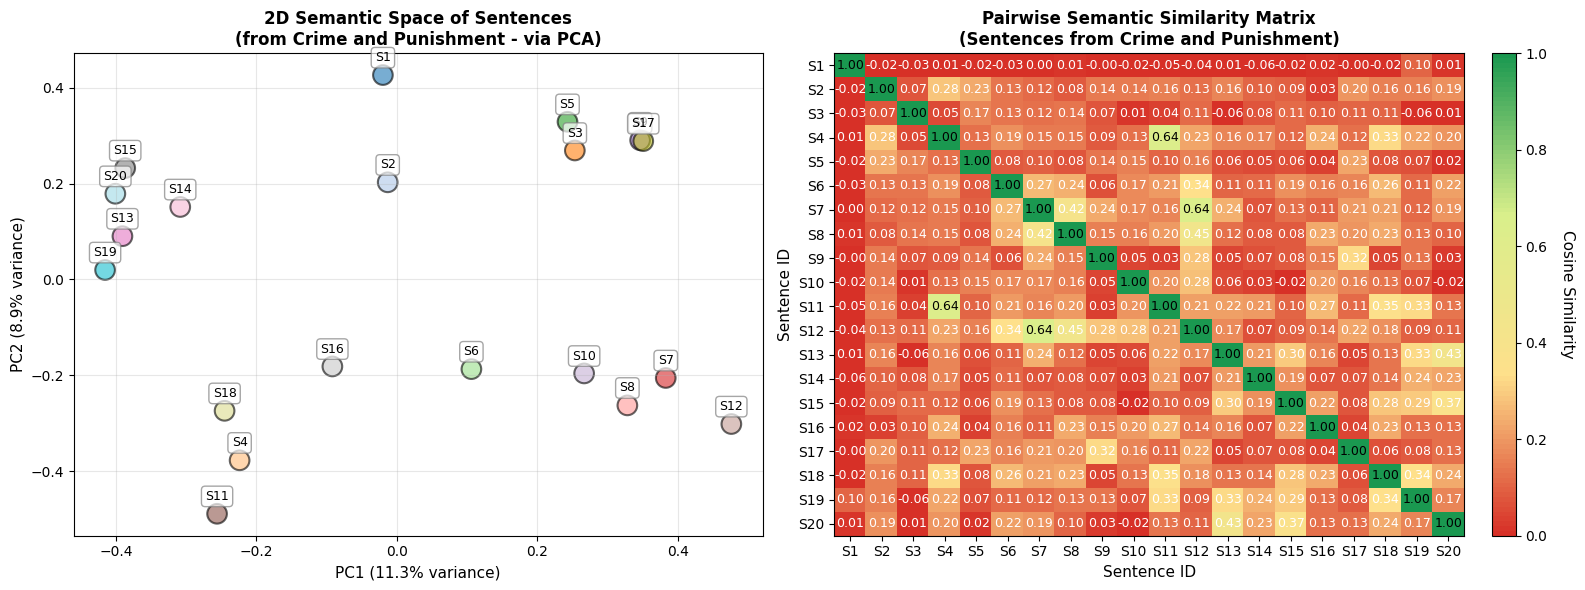


SENTENCE REFERENCE (Random Sample):
S1: I took off the paper, saw
some little hooks, undid them, and in the box were
the ear-rings
S2: Well, the painter is mixed up
in it
S3: Do I love her
S4: “And he’s drawn his sister in; that’s quite,
quite in keeping with Avdotya Romanovna’s charac-
ter
S5: Yes, that’s so
S6: Sometimes one can’t stand things.”
    “Can’t stand that?”
    “Why, could you stand it then
S7: “I’ve been talking nonsense a long
time
S8: Don’t take any notice: I
am talking nonsense, I am not worthy of you
S9: It’s a disgusting and
ridiculous suspicion
S10: “It’s not a province, your excellency, but a district
S11: .”
    Avdotya Romanovna could not finish
S12: “No, it’s not nonsense
S13: And that half-hour he
had lost over an irrational plan, simply because he
had thought of it in delirium
S14: Marmeladov struck his fist resolutely on the table
S15: Never, never had he felt himself so fearfully alone
S16: Why, even if I were guilty, which I don’t admit,
what reason shoul

In [11]:
# --- Cell 3: Visualization (Titles Modified) ---

# Create a more comprehensive visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: 2D PCA Visualization ---\n",
pca = PCA(n_components=2)
points = pca.fit_transform(embeddings)

ax1 = axes[0]
scatter = ax1.scatter(points[:, 0], points[:, 1], c=range(len(sentences)), 
                      cmap='tab20', s=200, alpha=0.6, edgecolors='black', linewidth=1.5)

# Add labels with better positioning
for i, (s, (x, y)) in enumerate(zip(sentences, points)):
    # Use numbered labels for the plot, we will print the reference below
    label = f"S{i+1}"
    ax1.annotate(label, (x, y), fontsize=9, ha='center', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray'),
                xytext=(0, 10), textcoords='offset points')

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
# --- TITLE MODIFIED ---
ax1.set_title("2D Semantic Space of Sentences\n(from Crime and Punishment - via PCA)", 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# --- Plot 2: Similarity Heatmap ---\n",
from matplotlib.colors import LinearSegmentedColormap

# Compute cosine similarity matrix\n",
similarity_matrix = util.cos_sim(embeddings, embeddings).numpy()

ax2 = axes[1]
# Create custom colormap
colors = ['#d73027', '#fee08b', '#d9ef8b', '#1a9850']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('similarity', colors, N=n_bins)

im = ax2.imshow(similarity_matrix, cmap=cmap, aspect='auto', vmin=0, vmax=1)

# Add colorbar
cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('Cosine Similarity', rotation=270, labelpad=20, fontsize=11)

# Set ticks and labels
ax2.set_xticks(range(len(sentences)))
ax2.set_yticks(range(len(sentences)))
short_labels = [f"S{i+1}" for i in range(len(sentences))]
ax2.set_xticklabels(short_labels, fontsize=10)
ax2.set_yticklabels(short_labels, fontsize=10)

# Add similarity scores as text
for i in range(len(sentences)):
    for j in range(len(sentences)):
        text_color = 'white' if similarity_matrix[i, j] < 0.5 else 'black'
        ax2.text(j, i, f'{similarity_matrix[i, j]:.2f}',
                ha="center", va="center", color=text_color, fontsize=9)

# --- TITLE MODIFIED ---
ax2.set_title("Pairwise Semantic Similarity Matrix\n(Sentences from Crime and Punishment)", 
              fontsize=12, fontweight='bold')
ax2.set_xlabel("Sentence ID", fontsize=11)
ax2.set_ylabel("Sentence ID", fontsize=11)

plt.tight_layout()
plt.show()

# Print the sentences for reference
print("\n" + "="*80)
print("SENTENCE REFERENCE (Random Sample):")
print("="*80)
for i, sent in enumerate(sentences):
    print(f"S{i+1}: {sent}")
print("="*80)

### Interpreting the Results

**Left Plot - 2D Semantic Space:**
- Sentences with similar meanings cluster together in the vector space
- Distance between points indicates semantic dissimilarity
- PCA reduces the 384-dimensional embeddings to 2D for visualization
- Note: Some information is lost in dimension reduction (see variance percentages)

**Right Plot - Similarity Matrix:**
- Values range from 0 (completely dissimilar) to 1 (identical)
- Diagonal values are always 1.0 (sentence compared to itself)
- Higher values (green) indicate semantically similar sentences
- Lower values (red) indicate semantically different sentences

**Key Observations:**
- Paraphrases (e.g., "Alice looked at the cat" vs "The cat stared back at Alice") show high similarity
- Semantically related sentences cluster together in both visualizations
- Unrelated sentences have low similarity scores despite being grammatically correct

In [5]:
# Example: Finding most similar sentence pairs
print("\nTOP 5 MOST SIMILAR SENTENCE PAIRS:")
print("="*80)

# Get upper triangle indices (avoid duplicates and self-comparisons)
pairs = []
for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        pairs.append((i, j, similarity_matrix[i, j]))

# Sort by similarity score
pairs.sort(key=lambda x: x[2], reverse=True)

# Display top 5
for rank, (i, j, score) in enumerate(pairs[:5], 1):
    print(f"{rank}. Similarity: {score:.4f}")
    print(f"   S{i+1}: {sentences[i]}")
    print(f"   S{j+1}: {sentences[j]}")
    print()


TOP 5 MOST SIMILAR SENTENCE PAIRS:
1. Similarity: 0.4188
   S15: He got up, put
on his still damp jacket and overcoat
   S18: To work.” He got up from the table and
took up his cap

2. Similarity: 0.4058
   S10: Terror
gripped his heart like ice, tortured him and numbed
him
   S11: But in the last
resort he simply ceased to believe in himself, and
doggedly, slavishly sought arguments in all directions,
fumbling for them, as though some one were forcing
and drawing him to it

3. Similarity: 0.3837
   S8: But we will talk about her character


                           197
                  fyodor dostoevsky

later
   S19: For that’s
Katerina Ivanovna’s character, and when children
cry, even from hunger, she falls to beating them at
once

4. Similarity: 0.3745
   S4: to do something
   S18: To work.” He got up from the table and
took up his cap

5. Similarity: 0.3633
   S5: ‘You are not the murderer
   S14: “I’ll take you all, get in!”


                          90
                c

In [12]:
# Load pre-trained sentence transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Take a random sample of 20 sentences from the book
if 'brothers_sents' in locals() and brothers_sents:
    sample_size = 20
    # Ensure we don't sample more sentences than we have
    if len(brothers_sents) > sample_size:
        sentences = random.sample(brothers_sents, sample_size)
    else:
        sentences = brothers_sents
    
    print(f"--- Using {len(sentences)} random sentences from The Brothers Karamazov ---")

else:
    print("Book data not loaded. Please ensure 'brothers_sents' is defined.")
    sentences = [
        "The brothers discussed their father.", 
        "Alyosha smiled gently.",
        "Ivan argued with passion.",
        "Mitya was nowhere to be found.",
        "The monastery bells rang out.",
        "Money was the root of the problem.",
        "Faith and reason clashed.",
        "The trial began the next day."
    ]

# Generate embeddings
embeddings = model.encode(sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented as a {embeddings.shape[1]}-dimensional vector\n")

--- Using 20 random sentences from The Brothers Karamazov ---
Embedding shape: (20, 384)
Each sentence is represented as a 384-dimensional vector



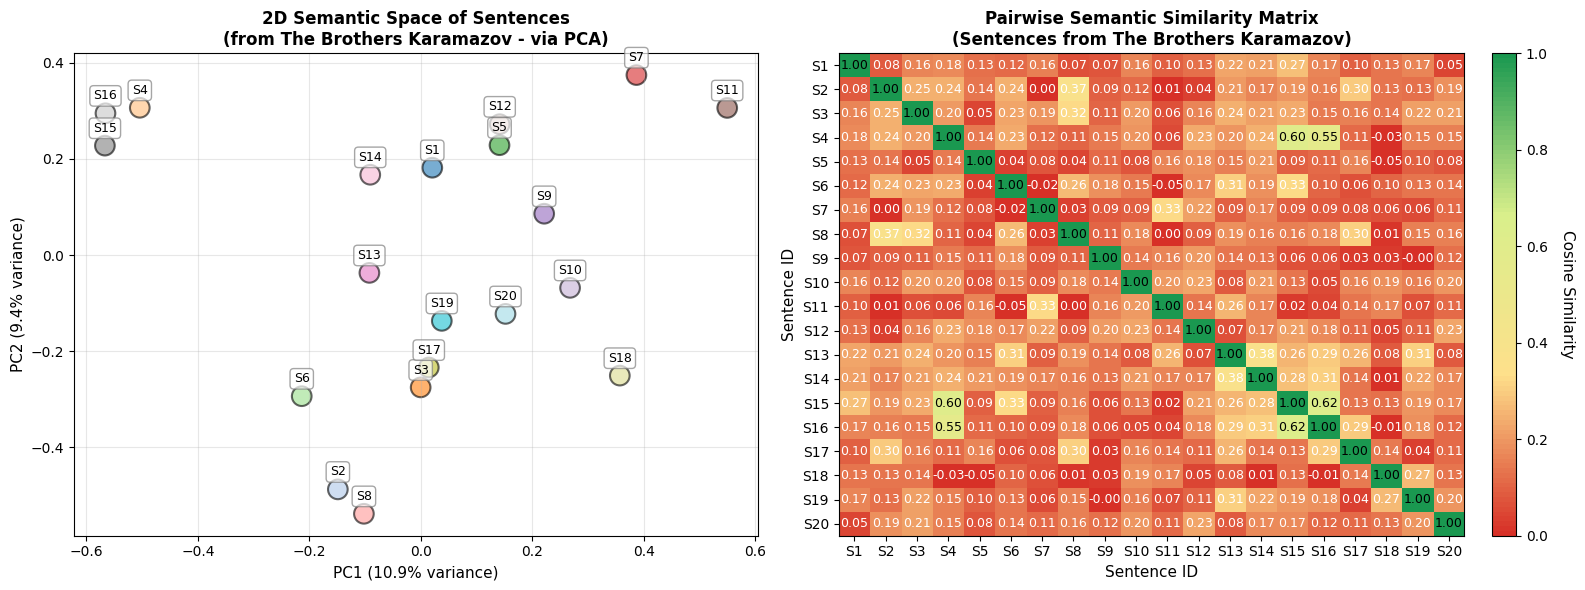


SENTENCE REFERENCE (The Brothers Karamazov Sample):
S1: There was a bright moon in the sky
S2: In the evening there was another trouble in store for Fyodor Pavlovitch; he was informed that Grigory, who had not been well for the last three days, was completely laid up by his lumbago
S3: “That’s a smoky topaz,” said Nikolay Parfenovitch, smiling
S4: Alyosha jumped up and cried, “He is ill
S5: We are late; it’s irregular
S6: He was furious, and conscious of being ridiculous
S7: I shall always be glad to see you
S8: One piece of Pyotr Ilyitch’s evidence made a great impression on the prosecutor and the investigating magistrate, namely, his idea that Dmitri Fyodorovitch would shoot himself before daybreak, that he had resolved to do so, had spoken of it to Ilyitch, had taken the pistols, loaded them before him, written a letter, put it in his pocket, etc
S9: If you kick me, you must believe in my reality, for people don’t kick ghosts
S10: In despair I wrote to Count Mattei in Milan
S11: I’

In [15]:
# Create a more comprehensive visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: 2D PCA Visualization ---
pca = PCA(n_components=2)
points = pca.fit_transform(embeddings)

ax1 = axes[0]
# Scatter plot
scatter = ax1.scatter(points[:, 0], points[:, 1], c=range(len(sentences)), 
                      cmap='tab20', s=200, alpha=0.6, edgecolors='black', linewidth=1.5)

# Add labels with better positioning
for i, (s, (x, y)) in enumerate(zip(sentences, points)):
    # Use numbered labels S1, S2, etc.
    label = f"S{i+1}"
    ax1.annotate(label, (x, y), fontsize=9, ha='center', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray'),
                xytext=(0, 10), textcoords='offset points')

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)

# --- TITLE SET FOR THE BROTHERS KARAMAZOV ---
ax1.set_title("2D Semantic Space of Sentences\n(from The Brothers Karamazov - via PCA)", 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# --- Plot 2: Similarity Heatmap ---

# Compute cosine similarity matrix
similarity_matrix = util.cos_sim(embeddings, embeddings).numpy()

ax2 = axes[1]
# Create custom colormap (Red -> Yellow -> Green)
colors = ['#d73027', '#fee08b', '#d9ef8b', '#1a9850']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('similarity', colors, N=n_bins)

im = ax2.imshow(similarity_matrix, cmap=cmap, aspect='auto', vmin=0, vmax=1)

# Add colorbar
cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('Cosine Similarity', rotation=270, labelpad=20, fontsize=11)

# Set ticks and labels
ax2.set_xticks(range(len(sentences)))
ax2.set_yticks(range(len(sentences)))
short_labels = [f"S{i+1}" for i in range(len(sentences))]
ax2.set_xticklabels(short_labels, fontsize=10)
ax2.set_yticklabels(short_labels, fontsize=10)

# Add similarity scores as text inside the squares
for i in range(len(sentences)):
    for j in range(len(sentences)):
        # Choose text color based on background darkness for readability
        text_color = 'white' if similarity_matrix[i, j] < 0.5 else 'black'
        ax2.text(j, i, f'{similarity_matrix[i, j]:.2f}',
                ha="center", va="center", color=text_color, fontsize=9)

# --- TITLE SET FOR THE BROTHERS KARAMAZOV ---
ax2.set_title("Pairwise Semantic Similarity Matrix\n(Sentences from The Brothers Karamazov)", 
              fontsize=12, fontweight='bold')
ax2.set_xlabel("Sentence ID", fontsize=11)
ax2.set_ylabel("Sentence ID", fontsize=11)

plt.tight_layout()
plt.show()

# Print the sentences for reference
print("\n" + "="*80)
print("SENTENCE REFERENCE (The Brothers Karamazov Sample):")
print("="*80)
for i, sent in enumerate(sentences):
    print(f"S{i+1}: {sent}")
print("="*80)